# Grover's Algorithm

## Lecture 5

### Last Time
Shor's Algorithm: Factoring --> Order finding --> Quantum Phase Estimation --> Continued Fractions

### Today
1. Grover's Algorithm for Unstructured Search
2. Qiskit simulation of Grover search

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, StatePreparation
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=4, suppress=True)


def bits(j, n):
    return format(j, f'0{n}b')


def qft_circuit(n, do_swaps=True):
    qc = QuantumCircuit(n, name='QFT')
    for target in reversed(range(n)):
        qc.h(target)
        for control in reversed(range(target)):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
    if do_swaps:
        for q in range(n // 2):
            qc.swap(q, n - q - 1)
    return qc

# Search Problems

Grover's algorithm solves an unstructured search problem.

We have a search space of size

$$N=2^n,$$

whose elements are represented by computational basis states

$$|0\rangle, |1\rangle, \ldots, |N-1\rangle.$$

Some inputs are **marked**. The goal is to find a marked input using as few oracle calls as possible.

## Complexity

If there are $M$ marked items among $N$ total items, then a random classical guess succeeds with probability

$$\frac{M}{N}.$$

The expected number of checks is about

$$\frac{N}{M}.$$

If there is one marked item ($M = 1$), this is about $N$ checks.

Grover reduces this to

$$O\left(\sqrt{\frac{N}{M}}\right)$$

oracle calls.

## The phase oracle

Grover assumes a phase oracle $O_f$ that recognizes marked states:

$$O_f|x\rangle=(-1)^{f(x)}|x\rangle,$$

where

$$f(x)=\begin{cases}
1, & x\text{ is marked},\\
0, & x\text{ is unmarked}.
\end{cases}$$

So the oracle does not reveal the answer directly.

It only flips the sign of the marked amplitudes.

## From a checker to a phase oracle

Usually we first know how to build a reversible checker:

$$U_f|x\rangle|b\rangle=|x\rangle|b\oplus f(x)\rangle.$$

To turn this into a phase oracle, prepare the second qubit in

$$|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}.$$

Then

$$U_f|x\rangle|-\rangle
=|x\rangle\frac{|f(x)\rangle-|1\oplus f(x)\rangle}{\sqrt2}.$$

If $f(x)=0$, nothing changes.

If $f(x)=1$, the state becomes

$$-|x\rangle|-\rangle.$$

So the checker has become a phase oracle.

# The Starting State

Grover begins with the uniform superposition

$$|s\rangle=\frac{1}{\sqrt N}\sum_{x=0}^{N-1}|x\rangle.$$

This is easy to prepare:

$$|0\rangle^{\otimes n}\xrightarrow{H^{\otimes n}}|s\rangle.$$

At the start, every item has amplitude

$$\frac{1}{\sqrt N}.$$

The marked items are present, but they have tiny total probability when $M\ll N$.

## The diffuser: reflection around the average

The Grover diffuser is

$$D=2|s\rangle\langle s|-I.$$

For a state

$$|\psi\rangle=\sum_x a_x|x\rangle,$$

let the average amplitude be

$$\bar a=\frac{1}{N}\sum_x a_x.$$

Then the diffuser maps each amplitude to

$$a_x\mapsto 2\bar a-a_x.$$

That is why it is called **inversion about the mean**.

## Why $D$ reflects around the average

Start with

$$D|\psi\rangle=(2|s\rangle\langle s|-I)|\psi\rangle.$$

The overlap with the uniform state is

$$\langle s|\psi\rangle
=\left(\frac{1}{\sqrt N}\sum_y\langle y|\right)
\left(\sum_x a_x|x\rangle\right)
=\frac{1}{\sqrt N}\sum_x a_x
=\sqrt N\,\bar a.$$

Therefore

$$2|s\rangle\langle s|\psi\rangle
=2\sqrt N\,\bar a\left(\frac{1}{\sqrt N}\sum_x|x\rangle\right)
=2\bar a\sum_x|x\rangle.$$

Subtract $|\psi\rangle$:

$$D|\psi\rangle=\sum_x(2\bar a-a_x)|x\rangle.$$

## Constructing the Diffuser

The diffuser is

$$D=2|s\rangle\langle s|-I.$$

Since

$$|s\rangle=H^{\otimes n}|0\rangle,$$

we can rewrite

$$D=H^{\otimes n}(2|0\rangle\langle 0|-I)H^{\otimes n}.$$

$(2|0\rangle\langle 0|-I)$ just flips the phase of $|x\rangle$ if $x \neq 0$.

## One amplitude update by hand

Take $N=16$ and one marked state for a rough intuition.

Initially every amplitude is

$$\frac{1}{4}.$$

The oracle flips the marked amplitude:

$$\text{marked amplitude}:\quad \frac14\mapsto -\frac14.$$

The new average amplitude is

$$\bar a=\frac{15(1/4)+(-1/4)}{16}=\frac{14}{64}=\frac{7}{32}.$$

The diffuser maps each amplitude by

$$a_x\mapsto 2\bar a-a_x.$$

For the marked state:

$$-\frac14\mapsto 2\left(\frac{7}{32}\right)-\left(-\frac14\right)
=\frac{14}{32}+\frac{8}{32}=\frac{22}{32}=\frac{11}{16}.$$

One iteration made the marked amplitude much larger.

## One Grover iteration

A Grover iteration is

$$G=D O_f.$$

Read right to left:

1. $O_f$ flips the signs of marked amplitudes.
2. $D$ reflects all amplitudes around their average.

The first step pushes marked amplitudes below zero.

The second step reflects them high above the average.

Repeating this transfers amplitude from unmarked states into marked states.

# Two-Dimensional Picture

Let

$$|\beta\rangle=\frac{1}{\sqrt M}\sum_{x\text{ marked}}|x\rangle$$

be the equal superposition of marked states, and

$$|\alpha\rangle=\frac{1}{\sqrt{N-M}}\sum_{x\text{ unmarked}}|x\rangle$$

be the equal superposition of unmarked states.

The starting state is

$$|s\rangle
=\sqrt{\frac{N-M}{N}}|\alpha\rangle
+\sqrt{\frac{M}{N}}|\beta\rangle.$$

The entire algorithm stays in the plane spanned by $|\alpha\rangle$ and $|\beta\rangle$.

## Define the Grover angle

Write

$$|s\rangle=\sqrt{\frac{N-M}{N}}|\alpha\rangle
+\sqrt{\frac{M}{N}}|\beta\rangle = \cos\theta\,|\alpha\rangle+\sin\theta\,|\beta\rangle.$$

This gives

$$\sin\theta=\sqrt{\frac{M}{N}},$$

so

$$\theta=\arcsin\sqrt{\frac{M}{N}}.$$

The initial probability of measuring a marked state is

$$\sin^2\theta=\frac{M}{N}.$$

## What the two reflections do

The oracle acts as

$$O_f|\alpha\rangle=|\alpha\rangle,$$

because unmarked states are unchanged, and

$$O_f|\beta\rangle=-|\beta\rangle,$$

because marked states get a minus sign.

So $O_f$ is a reflection across the $|\alpha\rangle$ axis.

The diffuser

$$D=2|s\rangle\langle s|-I$$

is a reflection across the line pointing in the $|s\rangle$ direction.

$G = D O_f$ is a rotation by angle $2\theta$.

Let

$$
|s\rangle = \cos\theta\,|\alpha\rangle + \sin\theta\,|\beta\rangle = \begin{pmatrix}
\cos\theta \\
\sin\theta
\end{pmatrix}
$$

in the basis $\{|\alpha\rangle,|\beta\rangle\}$. The oracle is

$$
O_f =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}.
$$

The diffuser is

$$
D = 2|s\rangle\langle s| - I = 2
\begin{pmatrix}
\cos\theta \\
\sin\theta
\end{pmatrix}
\begin{pmatrix}
\cos\theta & \sin\theta
\end{pmatrix}
-
I
=
\begin{pmatrix}
\cos 2\theta & \sin 2\theta \\
\sin 2\theta & -\cos 2\theta
\end{pmatrix}.
$$

Therefore

$$
G = DO_f
=
\begin{pmatrix}
\cos 2\theta & \sin 2\theta \\
\sin 2\theta & -\cos 2\theta
\end{pmatrix}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
=
\begin{pmatrix}
\cos 2\theta & -\sin 2\theta \\
\sin 2\theta & \cos 2\theta
\end{pmatrix}.
$$

Thus $G$ is a rotation by angle $2\theta$ in the
$\{|\alpha\rangle,|\beta\rangle\}$ plane.

## The rotation formula

After $k$ Grover iterations,

$$G^k|s\rangle
=\cos((2k+1)\theta)|\alpha\rangle
+\sin((2k+1)\theta)|\beta\rangle.$$

Therefore the success probability is

$$P_{\text{success}}(k)=\sin^2((2k+1)\theta).$$

We want $(2k+1)\theta$ to be close to $\pi/2$.

Solve approximately:

$$2k\theta\approx\frac{\pi}{2},$$

so
$$k \approx \frac{\pi}{4 \theta}.$$

When $M \ll N$,

$$\theta\approx\sqrt{\frac{M}{N}},$$

so

$$k\approx\frac{\pi}{4}\sqrt{\frac{N}{M}}.$$

## Do not over-rotate

Grover does not monotonically improve forever.

Since each iteration is a rotation, the state can rotate past $|\beta\rangle$.

After that, the marked-state probability decreases.

This is why the iteration count matters:

$$k_{\text{opt}}\approx\left\lfloor\frac{\pi}{4}\sqrt{\frac{N}{M}}\right\rfloor.$$

If $M$ is unknown, one can use randomized iteration counts or amplitude estimation to learn the success amplitude.

# Visualizing Grover's Rotation

For a concrete example, take

$$N=16,\qquad M=2.$$

Then

$$\sin\theta=\sqrt{\frac{2}{16}}=\frac{1}{\sqrt8},$$

so

$$\theta\approx 0.361\text{ radians}.$$

The optimal number of iterations is about

$$\frac{\pi}{4}\sqrt{\frac{16}{2}}\approx 2.22,$$

so we expect $2$ Grover iterations to work well.

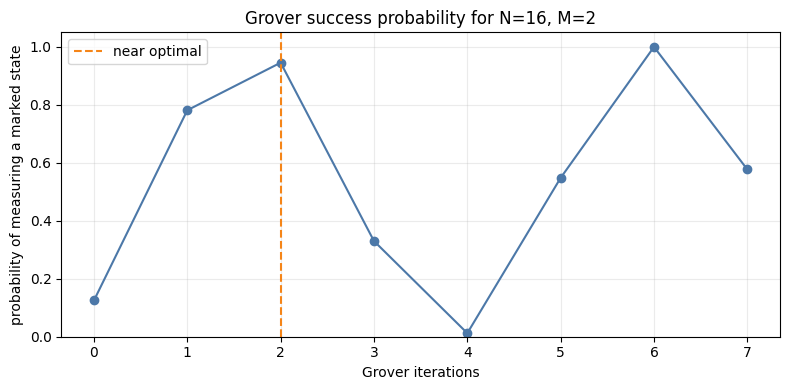

In [2]:
N = 16
M = 2
theta = np.arcsin(np.sqrt(M / N))
iterations = np.arange(0, 8)
success = np.sin((2 * iterations + 1) * theta) ** 2

plt.figure(figsize=(8, 4))
plt.plot(iterations, success, marker='o', color='#4c78a8')
plt.axvline(2, color='#f58518', linestyle='--', label='near optimal')
plt.ylim(0, 1.05)
plt.xlabel('Grover iterations')
plt.ylabel('probability of measuring a marked state')
plt.title('Grover success probability for N=16, M=2')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel(r'$|\alpha\rangle$ direction: unmarked')
ax.set_ylabel(r'$|\beta\rangle$ direction: marked')
ax.grid(alpha=0.25)
ax.plot([0, 1], [0, 0], color='black', linewidth=1)
ax.plot([0, 0], [0, 1], color='black', linewidth=1)

angles = (2 * iterations + 1) * theta
points = np.column_stack([np.cos(angles), np.sin(angles)])
ax.plot(points[:, 0], points[:, 1], color='#bab0ab', linestyle='--', marker='o', alpha=0.7)
vector, = ax.plot([], [], color='#e45756', linewidth=3)
label = ax.text(0.04, 0.95, '', transform=ax.transAxes, fontsize=12)

def update(frame):
    x, y = points[frame]
    vector.set_data([0, x], [0, y])
    label.set_text(f'k = {frame}, success = {success[frame]:.3f}')
    return vector, label

anim = FuncAnimation(fig, update, frames=len(iterations), interval=900, blit=True)
plt.close(fig)
display(HTML(anim.to_jshtml()))

# Qiskit Simulation: Grover Search

We will search a 4-qubit space:

$$N=2^4=16.$$

Mark two solutions:

$$|0110\rangle,\qquad |1011\rangle.$$

The exact implementation below uses matrix gates for the oracle and diffuser so that the math is transparent.

For larger real circuits, one would decompose these into reversible checking logic and multi-controlled phase gates.

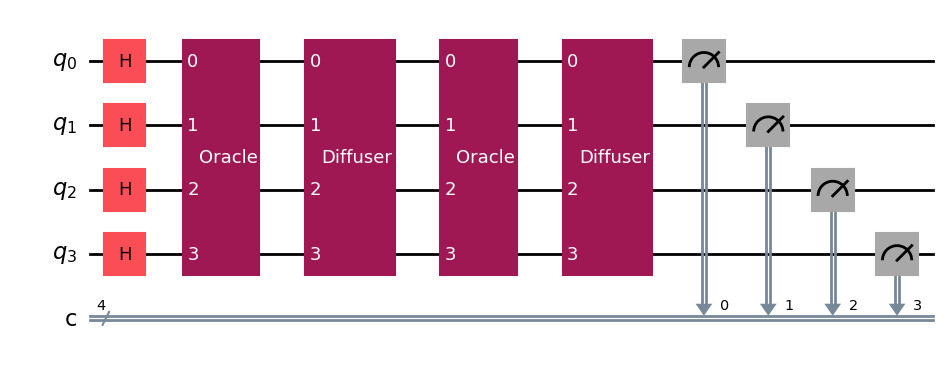

In [4]:
def phase_oracle_gate(n, marked_bitstrings):
    dim = 2 ** n
    diagonal = np.ones(dim, dtype=complex)
    for bitstring in marked_bitstrings:
        diagonal[int(bitstring, 2)] = -1
    return UnitaryGate(np.diag(diagonal), label='Oracle')


def diffuser_gate(n):
    dim = 2 ** n
    s = np.ones(dim, dtype=complex) / np.sqrt(dim)
    D = 2 * np.outer(s, s.conj()) - np.eye(dim)
    return UnitaryGate(D, label='Diffuser')


def grover_circuit(n, marked_bitstrings, iterations, measure=False):
    qc = QuantumCircuit(n, n if measure else 0)
    qc.h(range(n))

    oracle = phase_oracle_gate(n, marked_bitstrings)
    diffuser = diffuser_gate(n)

    for _ in range(iterations):
        qc.append(oracle, range(n))
        qc.append(diffuser, range(n))

    if measure:
        qc.measure(range(n), range(n))
    return qc


marked = ['0110', '1011']
grover_demo = grover_circuit(4, marked, iterations=2, measure=True)
grover_demo.draw(output='mpl')

In [5]:
def grover_probabilities(n, marked_bitstrings, max_iterations):
    rows = []
    for k in range(max_iterations + 1):
        qc = grover_circuit(n, marked_bitstrings, iterations=k, measure=False)
        state = Statevector.from_instruction(qc)
        probabilities = state.probabilities_dict()
        success_probability = sum(float(probabilities.get(bitstring, 0)) for bitstring in marked_bitstrings)
        rows.append((k, success_probability, probabilities))
    return rows


rows = grover_probabilities(4, marked, max_iterations=6)
for k, success_probability, _ in rows:
    print(f'{k} iterations: success probability = {success_probability:.4f}')

0 iterations: success probability = 0.1250
1 iterations: success probability = 0.7812
2 iterations: success probability = 0.9453
3 iterations: success probability = 0.3301
4 iterations: success probability = 0.0122
5 iterations: success probability = 0.5480
6 iterations: success probability = 0.9998


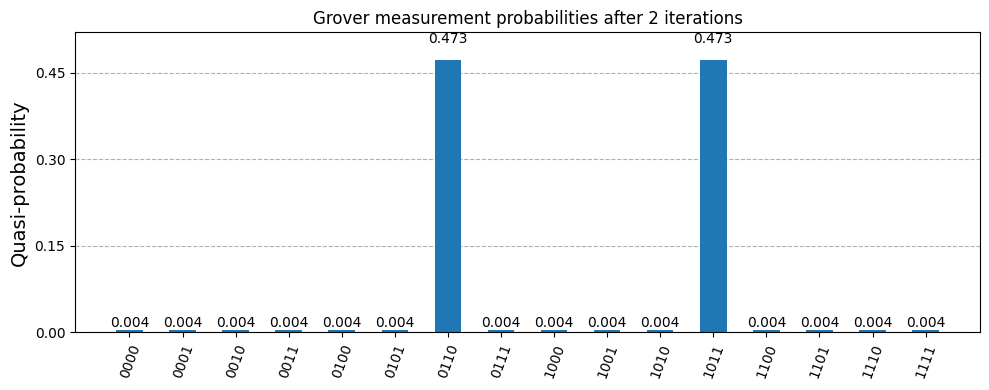

In [6]:
best_k = 2
_, _, best_probabilities = rows[best_k]
plot_histogram(best_probabilities, figsize=(10, 4), title=f'Grover measurement probabilities after {best_k} iterations')

## What the simulation shows

With no Grover iterations, the two marked states have total probability

$$\frac{2}{16}=0.125.$$

After one iteration, their total probability is already much larger.

After two iterations, the simulation gives success probability about

$$0.945.$$

After three iterations, the probability drops again because the state has over-rotated past the marked-state axis.